In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt
import seaborn as sns
from scipy import stats
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

In [2]:
# set Times New Roman as the default font for figure plotting
plt.rcParams['font.family'] = 'Times New Roman'

In [3]:
def tnr():
    font = "Times New Roman"
    
    return {
        "config" : {
             "title": {'font': font},
             "axis": {
                  "labelFont": font,
                  "titleFont": font
             },
             "header": {
                  "labelFont": font,
                  "titleFont": font
             },
             "legend": {
                  "labelFont": font,
                  "titleFont": font
             }
        }
    }

In [4]:
alt.themes.register('tnr', tnr)
alt.themes.enable('tnr')

ThemeRegistry.enable('tnr')

In [5]:
df=pd.read_excel('Tables/0_Supplementary_Table_1_365.xlsx')
df.shape

(365, 22)

In [6]:
meta=pd.read_csv('Tables/MTB_365_metadata_all_PRIVATE.csv')
meta.shape

(365, 45)

### Diversity profile of 365 MTB genomes

In [7]:
dfTaxa=df.loc[:,['Accession','ID','GTDB_r220_classification']]

In [8]:
taxa='phylum class order family genus species'.split(' ')
for i in range(len(taxa)):
    dfTaxa[taxa[i]]=dfTaxa.GTDB_r220_classification.apply(lambda x: x.split(';')[i+1])
dfTaxa.shape

(365, 9)

In [9]:
# summary the overall description of the DIVERSITY
for i in taxa:
    _taxa=dfTaxa[i]
    _unclassified=dfTaxa[_taxa.apply(lambda x: True if len(x)<=3 else False)].shape[0]
    _uni_len=len(_taxa.unique().tolist())
    
    print(f"The MTB genomes belong to {_uni_len} unique {i}.")   
    if _unclassified>0:
        print(f'\t !Note: For {i} level, {_unclassified} genomes cannot be classified into any konw {i}')


The MTB genomes belong to 16 unique phylum.
The MTB genomes belong to 35 unique class.
The MTB genomes belong to 49 unique order.
The MTB genomes belong to 89 unique family.
	 !Note: For family level, 1 genomes cannot be classified into any konw family
The MTB genomes belong to 128 unique genus.
	 !Note: For genus level, 11 genomes cannot be classified into any konw genus
The MTB genomes belong to 216 unique species.
	 !Note: For species level, 47 genomes cannot be classified into any konw species


In [10]:
# 11 genomes could not assigned to any known genus
dfTaxa[dfTaxa.genus.apply(lambda x: True if len(x)<=3 else False)]

,Accession,ID,GTDB_r220_classification,phylum,class,order,family,genus,species
10,GCA_000960725.1,GCA_000960725.1_Candidatus_Magnetoovum_chiemen...,d__Bacteria;p__Nitrospirota;c__Thermodesulfovi...,p__Nitrospirota,c__Thermodesulfovibrionia,o__Thermodesulfovibrionales,f__Magnetobacteriaceae,g__,s__
14,GCA_001303405.1,GCA_001303405.1_Nitrospira_bacterium_SG8_35_4,d__Bacteria;p__Nitrospirota;c__Thermodesulfovi...,p__Nitrospirota,c__Thermodesulfovibrionia,o__UBA6902,f__UBA6902,g__,s__
133,GCA_015231495.1,GCA_015231495.1_Planctomycetota_bacterium_nTSb...,d__Bacteria;p__Planctomycetota;c__JADGBV01;o__...,p__Planctomycetota,c__JADGBV01,o__JADGBV01,f__JADGBV01,g__,s__
266,GCA_022321425.1,GCA_022321425.1_Syntrophales_bacterium_LBB04,d__Bacteria;p__Desulfobacterota;c__Syntrophia;...,p__Desulfobacterota,c__Syntrophia,o__Syntrophales,f__JACQWR01,g__,s__
276,GCA_039908285.1,GCA_039908285.1_Alphaproteobacteria_bacterium_...,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__Rhodospirillaceae,g__,s__
277,GCA_039908345.1,GCA_039908345.1_Magnetospirillum_sp._WYHS-4,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales_A,f__GLO-3,g__,s__
280,GCA_039908395.1,GCA_039908395.1_Magnetococcus_sp._WYHC-3,d__Bacteria;p__Pseudomonadota;c__Magnetococcia...,p__Pseudomonadota,c__Magnetococcia,o__Magnetococcales,f__,g__,s__
283,GCA_039908535.1,GCA_039908535.1_Magnetococcus_sp._DMHC-6,d__Bacteria;p__Pseudomonadota;c__Magnetococcia...,p__Pseudomonadota,c__Magnetococcia,o__Magnetococcales,f__JADFZT01,g__,s__
296,IMG_2264265205,IMG_2264265205_Planctomycetes_bacterium_SCGC_J...,d__Bacteria;p__Planctomycetota;c__Phycisphaera...,p__Planctomycetota,c__Phycisphaerae,o__UBA1845,f__PWPN01,g__,s__
298,IMG_3300015153,IMG_3300015153_Omnitrophica_bacterium_SCGC_AG-...,d__Bacteria;p__Omnitrophota;c__Omnitrophia;o__...,p__Omnitrophota,c__Omnitrophia,o__Omnitrophales,f__Aquincolibacteriaceae,g__,s__


In [11]:
# 47 genomes could not assigned to any known species
accs_unclassified_species = dfTaxa[dfTaxa.species.apply(lambda x: True if len(x)<=3 else False)].Accession.tolist()
with open('accessions_unclassified_into_any_know_species_34.txt','w') as f:
    f.write('\n'.join(accs_unclassified_species)+'\n')
    
len(accs_unclassified_species)

47

In [12]:
# Sort the dfTaxa to generate the phyla distribution stacked-bar-plot
g=dfTaxa.groupby('phylum')
phyla_count=[(n, dftmp.shape[0]) for n, dftmp in g]
phyla_order=[i[0] for i in sorted(phyla_count, key=lambda x: x[1], reverse=True)]

dfs=[]
for n, dftmp in g:
    c_g=dftmp.groupby('class')
    class_count=[(c_n, c_dftmp.shape[0]) for c_n, c_dftmp in c_g]
    class_order=[i[0] for i in sorted(class_count, key=lambda x: x[1], reverse=True)]
    dftmp['class']=pd.Categorical(dftmp['class'], categories=class_order, ordered=True)
    dftmp.sort_values(by='class',inplace=True)
    dfs.append((phyla_order.index(n), dftmp))

dfTaxa_=pd.concat([i[1] for i in sorted(dfs, key=lambda x: x[0])])

class_list=dfTaxa_['class'].unique().tolist()
index_list=[i for i in 'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ']
dfTaxa_['order']=dfTaxa_['class'].apply(lambda x: index_list[class_list.index(x)])
dfTaxa_['oder_']=dfTaxa_['order']+'_'+dfTaxa_['class']

In [13]:
sorted(phyla_count, key=lambda x: x[1], reverse=True)

[('p__Pseudomonadota', 159),
 ('p__Desulfobacterota', 84),
 ('p__Nitrospirota', 45),
 ('p__Omnitrophota', 31),
 ('p__Bdellovibrionota', 13),
 ('p__Planctomycetota', 7),
 ('p__Nitrospinota', 6),
 ('p__SAR324', 5),
 ('p__Elusimicrobiota', 3),
 ('p__Hydrogenedentota', 3),
 ('p__Riflebacteria', 3),
 ('p__UBA10199', 2),
 ('p__Desulfobacterota_G', 1),
 ('p__Fibrobacterota', 1),
 ('p__Latescibacterota', 1),
 ('p__Myxococcota', 1)]

In [14]:
alt.Chart(dfTaxa_).mark_bar(
    cornerRadiusTopLeft=3,
    cornerRadiusTopRight=3,
    color='dimgrey'
).encode(
    x=alt.X('phylum:O', title = 'Phyla (based on GTDB release r220)', sort=None, axis=alt.Axis(labelAngle=-45)),
    y=alt.Y('count():Q', title='Number of published MTB genomes', sort=None),
    # color=alt.Color('oder_:N', sort=None),
).configure_axis(
    # grid=True,  # Enable grid
    gridDash=[3, 2]  # Set the grid lines to be dashed
)

alt.Chart(...)

In [15]:
alt.Chart(dfTaxa_.iloc[:323,:]).mark_bar(
    cornerRadiusTopLeft=3,
    cornerRadiusTopRight=3,
    # color='dimgrey'
).encode(
    x=alt.X('phylum:O', sort=None, axis=alt.Axis(labelAngle=-45)),
    y=alt.Y('count():Q', sort=None),
    color=alt.Color('oder_:N', sort=None),
)

alt.Chart(...)

### Genomic features of MTB genomes

In [16]:
df.columns

Index(['Accession', 'ID', 'GTDB_r220_classification', 'Number_of_contigs',
       'Size(bp)', 'GC (%)', 'N50', 'Number of CDS', 'Number of tRNAs',
       'tRNAs', 'Number of rRNA genes', 'Number of 5S rRNA gene',
       'Number of 16S rRNA gene', 'Number of 23S rRNA gene',
       'CheckM_completeness(%)', 'CheckM_contamination(%)',
       'CheckM2_completeness(%)(GB_model)',
       'CheckM2_completeness(%)(NN_model)', 'CheckM2_contamination(%)',
       'BUSCO_completeness(%)', 'BUSCO_contamination(%)', 'pass.GUNC'],
      dtype='object')

In [17]:
# Profile the overall genome quality
cc_df=df.loc[:,['CheckM_completeness(%)', 'CheckM_contamination(%)','Accession','ID']]
cc_df['quality']=cc_df.apply(lambda x: 'High' if x['CheckM_completeness(%)']>90 and x['CheckM_contamination(%)']<5 else 
            ('Medium' if x['CheckM_completeness(%)']>=50 and x['CheckM_contamination(%)']<10 else 
             ('Low' if x['CheckM_completeness(%)']<50 and x['CheckM_contamination(%)']<10 else 'Bad')), axis=1)
g=cc_df.groupby(by='quality')

quality_group=[]
quality_count=[]
for n,dftmp in g:
    quality_group.append(n)
    quality_count.append(dftmp.shape[0])
    print(f"{dftmp.shape[0]} MTB genomes belong to {n} quality") 

6 MTB genomes belong to Bad quality
176 MTB genomes belong to High quality
4 MTB genomes belong to Low quality
179 MTB genomes belong to Medium quality


In [28]:
bad_list = cc_df[cc_df.quality=='Bad'].Accession.tolist()
meta[meta.Accession.apply(lambda x: True if x in bad_list else False)].GTDB_r220_classification.tolist()

['d__Bacteria;p__Desulfobacterota;c__Desulfobacteria;o__Desulfobacterales;f__Magnetomoraceae;g__Magnetomorum;s__',
 'd__Bacteria;p__Omnitrophota;c__Koll11;o__Tantalellales;f__Tantalellaceae;g__Omnitrophus_A;s__Omnitrophus_A magneticus',
 'd__Bacteria;p__Nitrospirota;c__Thermodesulfovibrionia;o__Thermodesulfovibrionales;f__Magnetobacteriaceae;g__;s__',
 'd__Bacteria;p__Nitrospirota;c__Thermodesulfovibrionia;o__Thermodesulfovibrionales;f__Magnetobacteriaceae;g__Magnetobacterium;s__',
 'd__Bacteria;p__Nitrospirota;c__Thermodesulfovibrionia;o__UBA6902;f__UBA6902;g__;s__',
 'd__Bacteria;p__Pseudomonadota;c__Magnetococcia;o__Magnetococcales;f__JADFXB01;g__JADFXB01;s__JADFXB01 sp015233935']

In [29]:
quality_group

['Bad', 'High', 'Low', 'Medium']

In [30]:
# Plot the pie chart illustrate the propotion of each quality group

source = pd.DataFrame(
    {"group": ['dBad', 'aHigh','cLow','bMedium',], "value": quality_count}
)

base = alt.Chart(source).encode(
    alt.Theta("value:Q").stack(True),
    alt.Color("group:N", scale=alt.Scale(domain=['aHigh', 'bMedium', 'cLow','dBad'], range=['#D62828','#21B1FF','#FFD800','#495057'])).legend(None)
)

pie = base.mark_arc(outerRadius=120, stroke="#000000", strokeWidth=2)
text1 = base.mark_text(radius=160, size=20).encode(text="group:N")
text2 = base.mark_text(radius=200, size=20).encode(text="value:Q")

pie + text1 + text2


alt.LayerChart(...)

In [31]:
cc_df_=cc_df[cc_df.quality!='Bad']

In [32]:
base = alt.Chart(cc_df_)
base_bar = base.mark_bar(
    opacity=0.7, 
    binSpacing=1,
    stroke='black',  # Set edge color
    strokeWidth=0.3,
)

xscale = alt.Scale(domain=(30, 100))
yscale = alt.Scale(domain=(0, 10))

points = base.mark_circle(
    size=45,
    stroke='black',  # Set edge color
    strokeWidth=0.3,  # Set edge width
    opacity=0.6
).encode(
    alt.X('CheckM_completeness(%)', title='CheckM completeness (%)').scale(xscale),
    alt.Y('CheckM_contamination(%)', title='CheckM contamination (%)').scale(yscale),
    color=alt.Color('quality', scale=alt.Scale(domain=['High', 'Medium', 'Low'], range=['#D62828','#21B1FF','#FFD800'])),
    tooltip=[
        alt.Tooltip('CheckM_completeness(%):Q', title='com'),
        alt.Tooltip('CheckM_contamination(%):Q', title='con'),
        alt.Tooltip('Accession:N', title='acc'),
        # alt.Tooltip('size:Q', title='大小')  # 添加额外信息
    ]
).interactive()

top_hist = (
    base_bar
    .encode(
        alt.X("CheckM_completeness(%):Q")
            # when using bins, the axis scale is set through
            # the bin extent, so we do not specify the scale here
            # (which would be ignored anyway)
            .bin(maxbins=20, extent=xscale.domain).stack(None).title(""),
        alt.Y("count()", scale=alt.Scale(domain=(0, 120))).stack(None).title(""),
        color=alt.Color('quality', scale=alt.Scale(domain=['High', 'Medium', 'Low'], range=['#D62828','#21B1FF','#FFD800'])),
    )
    .properties(height=60)
)

right_hist = (
    base_bar
    .encode(
        alt.Y("CheckM_contamination(%):Q")
            .bin(maxbins=20, extent=yscale.domain)
            .stack(None)
            .title(""),
        alt.X("count()", scale=alt.Scale(domain=(0, 50))).stack(None).title(""),
        color=alt.Color('quality', scale=alt.Scale(domain=['High', 'Medium', 'Low'], range=['#D62828','#21B1FF','#FFD800'])),
    )
    .properties(width=60)
)

top_hist & (points | right_hist)

alt.VConcatChart(...)

In [33]:
gc_df=df.loc[:,['Accession','GC (%)','Size(bp)','GTDB_r220_classification']]
gc_df['phylum']=gc_df.GTDB_r220_classification.apply(lambda x: x.split(';')[1])

phyla_order=['p__Pseudomonadota',
 'p__Desulfobacterota',
 'p__Nitrospirota',
 'p__Omnitrophota',
 'p__Bdellovibrionota',
 'p__Planctomycetota',
 'p__Nitrospinota',
 'p__SAR324',
 'p__Elusimicrobiota',
 'p__Hydrogenedentota',
 'p__Riflebacteria',
 'p__UBA10199',
 'p__Desulfobacterota_G',
 'p__Fibrobacterota',
 'p__Latescibacterota',
 'p__Myxococcota']
index_prefix=[i for i in 'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ']

gc_df['phylum_']=gc_df.phylum.apply(lambda x: index_prefix[phyla_order.index(x)]+'_'+x)


In [34]:
gc_df['Size(Mb)']=gc_df['Size(bp)'].apply(lambda x: round(x/1000000, 2))

In [35]:
# GC/size chart use dot-dash plot

legend_order=gc_df.phylum_.unique().tolist()
legend_order.sort()

color_scale = alt.Scale(domain=legend_order, 
                        range="#d00000, #ffba08, #cbff8c, #8fe388, #1b998b, #3185fc, #5d2e8c, #46237a, #ff7b9c, #ff9b85, #cb997e, #ddbea9, #ffe8d6, #b7b7a4, #a5a58d, #6b705c".split(', '))

# Configure the options common to all layers
brush = alt.selection_interval()
base = alt.Chart(gc_df).add_params(brush)

# Configure the points
points = base.mark_circle(
    size=45,
    stroke='black',  # Set edge color
    strokeWidth=0.5,  # Set edge width
    opacity=0.7
    
).encode(
    x=alt.X('Size(Mb)', title='', scale=alt.Scale(domain=[0, 15]), axis=alt.Axis(ticks=False, domain=False, labels=False, tickCount=4)),
    y=alt.Y('GC (%)', title='', scale=alt.Scale(domain=[30, 70]),axis=alt.Axis(ticks=False, domain=False, labels=False)),
    color=alt.condition(brush, alt.Color('phylum_:N', scale=color_scale, sort=None), alt.value('grey'))
).properties(
    width=200,
    height=200
)

x_ticks = base.mark_tick(size=7).encode(
    alt.X('Size(Mb)', title='Size (Mb)', scale=alt.Scale(domain=[0, 15]), axis=alt.Axis(tickCount=4)),
    alt.Y('phylum_', title='', axis=alt.Axis(ticks=False, domain=False, labels=False)),
    color=alt.condition(brush, alt.Color('phylum_:N', scale=color_scale, sort=None), alt.value('lightgrey'))
).properties(
    width=200,
    height=150
)

y_ticks = base.mark_tick(size=7).encode(
    alt.X('phylum_', title='', axis=alt.Axis(ticks=False, domain=False, labels=False)),
    alt.Y('GC (%)', axis=alt.Axis(tickCount=4), scale=alt.Scale(domain=[30, 70])),
    color=alt.condition(brush, alt.Color('phylum_:N', scale=color_scale, sort=None), alt.value('lightgrey'))
).properties(
    width=150, 
    height=200
)

# Build the chart
y_ticks | (points & x_ticks)

# points

alt.HConcatChart(...)

In [36]:
# other genomic feature
fea_df=df.loc[:,['Number_of_contigs', 'N50', 'Number of CDS', 'Number of tRNAs','Number of 5S rRNA gene','Number of 16S rRNA gene', 'Number of 23S rRNA gene',]]
fea_df

,Number_of_contigs,N50,Number of CDS,Number of tRNAs,Number of 5S rRNA gene,Number of 16S rRNA gene,Number of 23S rRNA gene
0,1,4967148,4617,20,2,2,2
1,3,5248049,4554,21,3,3,3
2,1,4719581,3912,20,3,3,3
3,203,55386,4509,21,1,1,1
4,138,23078,1507,11,1,0,1
...,...,...,...,...,...,...,...
360,281,16894,2857,19,0,1,0
361,350,13468,2871,17,1,0,0
362,702,4840,3072,14,0,0,0
363,1,5043095,3907,20,3,3,3


In [51]:
gc_df.describe()

,GC (%),Size(bp),Size(Mb)
count,365.000000,3.650000e+02,365.000000
mean,51.673589,3.674341e+06,3.674219
std,8.636683,1.348709e+06,1.348908
min,31.520000,8.997970e+05,0.900000
25%,46.500000,2.891406e+06,2.890000
50%,51.410000,3.629071e+06,3.630000
75%,58.000000,4.339321e+06,4.340000
max,68.880000,1.414626e+07,14.150000


In [52]:
# Size(Mb)
gaussian_jitter = alt.Chart(gc_df).mark_circle(
    size=8,
    color='grey',
    stroke='black',
    strokeWidth=0.5,
    opacity=0.6
).encode(
    x=alt.X("Size(Mb):Q", title='Size(Mb)'),
    yOffset="jitter:Q",
).transform_calculate(
    # Generate Gaussian jitter with a Box-Muller transform
    jitter="sqrt(-2*log(random()))*cos(2*PI*random())"
)

box = alt.Chart(gc_df).mark_boxplot(
    color='black',
    outliers=False, 
    ticks=True, 
    opacity=0.6
).encode(
    x=alt.X("Size(Mb):Q", title=''),
)
gaussian_jitter + box

alt.LayerChart(...)

In [54]:
# Size(Mb)
gaussian_jitter = alt.Chart(gc_df).mark_circle(
    size=8,
    color='grey',
    stroke='black',
    strokeWidth=0.5,
    opacity=0.6
).encode(
    x=alt.X("GC (%):Q", title='GC (%)'),
    yOffset="jitter:Q",
).transform_calculate(
    # Generate Gaussian jitter with a Box-Muller transform
    jitter="sqrt(-2*log(random()))*cos(2*PI*random())"
)

box = alt.Chart(gc_df).mark_boxplot(
    color='black',
    outliers=False, 
    ticks=True, 
    opacity=0.6
).encode(
    x=alt.X("GC (%):Q", title=''),
)
gaussian_jitter + box

alt.LayerChart(...)

In [37]:
(fea_df['Number of 5S rRNA gene']>0) & (fea_df['Number of 16S rRNA gene']>0) & (fea_df['Number of 23S rRNA gene']>0)

0       True
1       True
2       True
3       True
4      False
       ...  
360    False
361    False
362    False
363     True
364    False
Length: 365, dtype: bool

In [38]:
rRNACount=[]
Num5s=fea_df[fea_df['Number of 5S rRNA gene']>0].shape[0]
Num16s=fea_df[fea_df['Number of 16S rRNA gene']>0].shape[0]
Num23s=fea_df[fea_df['Number of 23S rRNA gene']>0].shape[0]
NumAll=fea_df[(fea_df['Number of 5S rRNA gene']>0) & (fea_df['Number of 16S rRNA gene']>0) & (fea_df['Number of 23S rRNA gene']>0)].shape[0]
rRNACount.extend([Num5s,Num16s,Num23s, NumAll])

rRNACount

[239, 147, 153, 102]

In [39]:
# rRNA count
data=pd.DataFrame(data={'rRNAcount':rRNACount})
gaussian_jitter = alt.Chart(data).mark_circle(
    size=8,
    color='grey',
    stroke='black',
    strokeWidth=0.5,
    opacity=0.6
).encode(
    x=alt.X("rRNAcount:Q", title='Number of genomes with rRNA genes', scale=alt.Scale(domain=(0,348))),
)

gaussian_jitter

alt.Chart(...)

In [40]:
# Number of contigs
gaussian_jitter = alt.Chart(fea_df).mark_circle(
    size=8,
    color='grey',
    stroke='black',
    strokeWidth=0.5,
    opacity=0.6
).encode(
    x=alt.X("Number_of_contigs:Q", title='Number of contigs'),
    yOffset="jitter:Q",
).transform_calculate(
    # Generate Gaussian jitter with a Box-Muller transform
    jitter="sqrt(-2*log(random()))*cos(2*PI*random())"
)

box = alt.Chart(fea_df).mark_boxplot(
    color='black',
    outliers=False, 
    ticks=True, 
    opacity=0.6
).encode(
    x=alt.X("Number_of_contigs:Q", title=''),
)
gaussian_jitter + box

alt.LayerChart(...)

In [41]:
# N50_1
gaussian_jitter = alt.Chart(fea_df).mark_circle(
    size=8,
    color='grey',
    stroke='black',
    strokeWidth=0.5,
    opacity=0.6
).encode(
    x="N50:Q",
    yOffset="jitter:Q",
).transform_calculate(
    # Generate Gaussian jitter with a Box-Muller transform
    jitter="sqrt(-2*log(random()))*cos(2*PI*random())"
)

box = alt.Chart(fea_df).mark_boxplot(color='black',outliers=False, ticks=True, opacity=0.6).encode(
    x="N50:Q",
)
gaussian_jitter + box

alt.LayerChart(...)

In [42]:
# N50_2
gaussian_jitter = alt.Chart(fea_df[fea_df.N50<=400000]).mark_circle(
    size=8,
    color='grey',
    stroke='black',
    strokeWidth=0.5,
    opacity=0.6
).encode(
    x="N50:Q",
    yOffset="jitter:Q",
).transform_calculate(
    # Generate Gaussian jitter with a Box-Muller transform
    jitter="sqrt(-2*log(random()))*cos(2*PI*random())"
)

box = alt.Chart(fea_df[fea_df.N50<=1000000]).mark_boxplot(color='black',outliers=False, ticks=True, opacity=0.6).encode(
    x="N50:Q",
)
gaussian_jitter + box

alt.LayerChart(...)

In [43]:
# Number of CDS
gaussian_jitter = alt.Chart(fea_df).mark_circle(
    size=8,
    color='grey',
    stroke='black',
    strokeWidth=0.5,
    opacity=0.6
).encode(
    x="Number of CDS:Q",
    yOffset="jitter:Q",
).transform_calculate(
    # Generate Gaussian jitter with a Box-Muller transform
    jitter="sqrt(-2*log(random()))*cos(2*PI*random())"
)

box = alt.Chart(fea_df).mark_boxplot(color='black',outliers=False, ticks=True,opacity=0.6).encode(
    x="Number of CDS:Q",
)
gaussian_jitter + box

alt.LayerChart(...)

In [44]:
# Number of tRNAs
gaussian_jitter = alt.Chart(fea_df).mark_circle(
    size=8,
    color='grey',
    stroke='black',
    strokeWidth=0.5,
    opacity=0.6
).encode(
    x="Number of tRNAs:Q",
    yOffset="jitter:Q",
).transform_calculate(
    # Generate Gaussian jitter with a Box-Muller transform
    jitter="sqrt(-2*log(random()))*cos(2*PI*random())"
)

box = alt.Chart(fea_df).mark_boxplot(color='black',outliers=False, ticks=True, opacity=0.6).encode(
    x="Number of tRNAs:Q",
)
gaussian_jitter + box

alt.LayerChart(...)

### Publish history

#### publish history

In [61]:
meta.columns

Index(['Accession', 'ID', 'GTDB_r220_classification', 'Number_of_contigs',
       'Size (bp)', 'GC (%)', 'N50', 'Number of CDS', 'Number of tRNAs',
       'tRNAs', 'Number of rRNA genes', 'Number of 5S rRNA gene',
       'Number of 16S rRNA gene', 'Number of 23S rRNA gene',
       'CheckM completeness(%)', 'CheckM contamination(%)',
       'CheckM2 completeness(%)(GB_model)',
       'CheckM2 completeness(%)(NN_model)', 'CheckM2 contamination(%)',
       'BUSCO completeness(%)', 'BUSCO contamination(%)', 'pass.GUNC',
       'Organism Name', 'Bioproject accession', 'Biosample accession',
       'WGS accession', 'Assembly level', 'Sequencing platform',
       'Submission date', 'Submitter', 'PMID', 'Publish_date', 'Title',
       'Author', 'DOI', 'Journal', 'Geographic location',
       'Geographic coordinates', 'latitude', 'longitude',
       'Geographic coordinates_reports_origin', 'Environment',
       'Environment (note)',
       'recognized_as_MTB_through_magnetic_cell_enrichment',
 

In [62]:
meta['Publish_date'].unique()

array([2005, 2009, 2012, 2014, 2013, 2015, 2010, 2017, 2016, 2018, 2020,
       2019, 2022, 2021, 2023, 2024])

In [63]:
g=meta.groupby('Publish_date')
years=[]
numbers=[]
magNum=[]
mgcNum=[]

for n, dftmp in g:
    years.append(n)
    numbers.append(dftmp.shape[0])
    magNum.append(dftmp[dftmp.recognized_as_MTB_through_magnetic_cell_enrichment=='Yes'].shape[0])
    mgcNum.append(dftmp[dftmp.recognized_as_putative_MTB_through_MGC_identification=='Yes'].shape[0])

_accumulate_df=pd.DataFrame(data={'Date':years,'ToNum':numbers, 'magNum':magNum, 'mgcNum':mgcNum})
_accumulate_df['ToAccu'] = _accumulate_df['ToNum'].cumsum()
_accumulate_df['ToMag'] = _accumulate_df['magNum'].cumsum()
_accumulate_df['ToMgc'] = _accumulate_df['mgcNum'].cumsum()
_accumulate_df

,Date,ToNum,magNum,mgcNum,ToAccu,ToMag,ToMgc
0,2005,1,1,0,1,1,0
1,2009,1,1,0,2,2,0
2,2010,1,1,0,3,3,0
3,2012,1,1,0,4,4,0
4,2013,2,2,0,6,6,0
5,2014,5,4,1,11,10,1
6,2015,3,3,0,14,13,1
7,2016,5,5,0,19,18,1
8,2017,6,4,2,25,22,3
9,2018,29,27,2,54,49,5


In [64]:
date=_accumulate_df.Date.tolist()*3
group=['Total']*16+['MTB genome']*16+['MGC-containing genome']*16
AccNum=_accumulate_df.ToAccu.tolist()+_accumulate_df.ToMag.tolist()+_accumulate_df.ToMgc.tolist()
AccFrame=pd.DataFrame(data={'Date':date, 'Group':group, 'Number':AccNum})


In [65]:
AccFrame['Date'] = AccFrame.Date.astype(str)
# AccFrame.Date

In [66]:
AccFrame

,Date,Group,Number
0,2005,Total,1
1,2009,Total,2
2,2010,Total,3
3,2012,Total,4
4,2013,Total,6
5,2014,Total,11
6,2015,Total,14
7,2016,Total,19
8,2017,Total,25
9,2018,Total,54


In [67]:
alt.Chart(AccFrame).mark_line(
    point=alt.OverlayMarkDef(filled=False, fill="white")
).encode(
    x=alt.X('Date:T', title='Timeline', scale=alt.Scale(domain=['2005', '2024']),axis=alt.Axis(ticks=True, labelAngle=-45, tickCount=15)), 

    # y=alt.Y('Number:Q',  axis=alt.Axis(gridDash=[1, 1])),
    y=alt.Y('Number:Q', title='Number of published MTB genomes', scale=alt.Scale(domain=[0, 400], nice=True), axis=alt.Axis(ticks=True, tickCount=8)),
    color='Group:N'
).configure_axis(
    grid=True,  # Enable grid
    gridDash=[3, 2]  # Set the grid lines to be dashed
)

alt.Chart(...)

#### phyla identification history

In [68]:
meta.columns

Index(['Accession', 'ID', 'GTDB_r220_classification', 'Number_of_contigs',
       'Size (bp)', 'GC (%)', 'N50', 'Number of CDS', 'Number of tRNAs',
       'tRNAs', 'Number of rRNA genes', 'Number of 5S rRNA gene',
       'Number of 16S rRNA gene', 'Number of 23S rRNA gene',
       'CheckM completeness(%)', 'CheckM contamination(%)',
       'CheckM2 completeness(%)(GB_model)',
       'CheckM2 completeness(%)(NN_model)', 'CheckM2 contamination(%)',
       'BUSCO completeness(%)', 'BUSCO contamination(%)', 'pass.GUNC',
       'Organism Name', 'Bioproject accession', 'Biosample accession',
       'WGS accession', 'Assembly level', 'Sequencing platform',
       'Submission date', 'Submitter', 'PMID', 'Publish_date', 'Title',
       'Author', 'DOI', 'Journal', 'Geographic location',
       'Geographic coordinates', 'latitude', 'longitude',
       'Geographic coordinates_reports_origin', 'Environment',
       'Environment (note)',
       'recognized_as_MTB_through_magnetic_cell_enrichment',
 

In [69]:
df['phylum']=df['GTDB_r220_classification'].apply(lambda x: x.split(';')[1])
df.set_index('Accession',inplace=True)
df.sort_index(inplace=True)
# df

In [70]:
df

,ID,GTDB_r220_classification,Number_of_contigs,Size(bp),GC (%),N50,Number of CDS,Number of tRNAs,tRNAs,Number of rRNA genes,...,Number of 23S rRNA gene,CheckM_completeness(%),CheckM_contamination(%),CheckM2_completeness(%)(GB_model),CheckM2_completeness(%)(NN_model),CheckM2_contamination(%),BUSCO_completeness(%),BUSCO_contamination(%),pass.GUNC,phylum
Accession,,,,,,,,,,,,,,,,,,,,,
GCA_000009985.1,GCA_000009985.1_Magnetospirillum_magneticum_AMB-1,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,1,4967148,65.09,4967148,4617,20,"{'Tyr', 'Lys', 'Thr', 'Val', 'Glu', 'Ser', 'As...",6,...,2,99.00,0.00,100.00,100.00,1.31,94.3,0.8,True,p__Pseudomonadota
GCA_000010665.1,GCA_000010665.1_Solidesulfovibrio_magneticus_RS-1,d__Bacteria;p__Desulfobacterota;c__Desulfovibr...,3,5315620,62.67,5248049,4554,21,"{'SeC', 'Tyr', 'Lys', 'Thr', 'Val', 'Glu', 'Se...",9,...,3,100.00,0.00,98.92,100.00,0.53,93.5,0.8,True,p__Desulfobacterota
GCA_000014865.1,GCA_000014865.1_Magnetococcus_marinus_MC-1,d__Bacteria;p__Pseudomonadota;c__Magnetococcia...,1,4719581,54.17,4719581,3912,20,"{'Tyr', 'Lys', 'Thr', 'Val', 'Glu', 'Ser', 'As...",9,...,3,98.32,0.84,100.00,99.99,0.28,99.2,0.0,True,p__Pseudomonadota
GCA_000342045.1,GCA_000342045.1_Magnetospirillum_caucaseum_SO-1,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,203,4859560,65.99,55386,4509,21,"{'SeC', 'Tyr', 'Lys', 'Thr', 'Val', 'Glu', 'Se...",3,...,1,99.50,0.50,100.00,99.99,0.11,99.2,0.8,True,p__Pseudomonadota
GCA_000478645.1,GCA_000478645.1_Latescibacteria_bacterium_SCGC...,d__Bacteria;p__Latescibacterota;c__Latescibact...,138,1759976,40.86,23078,1507,11,"{'Ser', 'Asp', 'Arg', 'Met', 'Cys', 'Thr', 'Al...",2,...,1,43.99,0.00,42.87,47.72,0.00,46.0,0.0,True,p__Latescibacterota
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LMSG_G000037016.1,LMSG_G000037016.1_uncultured_gamma_proteobacte...,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,281,3172910,53.22,16894,2857,19,"{'Tyr', 'Lys', 'Thr', 'Val', 'Glu', 'Ser', 'As...",1,...,0,89.70,0.73,98.57,99.89,0.01,96.8,0.0,True,p__Pseudomonadota
LMSG_G000037017.1,LMSG_G000037017.1_uncultured_gamma_proteobacte...,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,350,3200600,55.07,13468,2871,17,"{'Tyr', 'Lys', 'Asp', 'Ser', 'Arg', 'Gln', 'Me...",1,...,0,88.26,2.23,94.05,95.19,0.63,90.3,0.0,True,p__Pseudomonadota
LMSG_G000037018.1,LMSG_G000037018.1_uncultured_Magnetaquicoccace...,d__Bacteria;p__Pseudomonadota;c__Magnetococcia...,702,3160004,57.78,4840,3072,14,"{'Lys', 'Ser', 'Arg', 'Gln', 'Cys', 'Met', 'Th...",0,...,0,76.27,0.96,87.42,85.30,3.70,71.0,0.0,True,p__Pseudomonadota


In [71]:
meta.set_index('Accession', inplace=True)
meta.sort_index(inplace=True)

In [72]:
(meta.index==df.index).all()

True

In [73]:
meta['phylum']=df['phylum']

In [74]:
_phyla_time=meta.loc[:,['Publish_date','phylum']]
_phyla_time.sort_values(by='Publish_date',inplace=True)
_phyla_time.drop_duplicates(subset='phylum',inplace=True)
_phyla_time

,Publish_date,phylum
Accession,,
GCA_000009985.1,2005,p__Pseudomonadota
GCA_000010665.1,2009,p__Desulfobacterota
GCA_000963235.1,2010,p__Nitrospirota
GCA_000478645.1,2014,p__Latescibacterota
GCA_000954095.1,2015,p__Omnitrophota
GCA_001303605.1,2017,p__Planctomycetota
GCA_002753255.1,2018,p__SAR324
GCA_015232855.1,2020,p__Fibrobacterota
GCA_015232735.1,2020,p__Bdellovibrionota


In [75]:
# phyla that contain only putative MTB
g=meta.groupby('phylum')

for n,dftmp in g:
    if (dftmp.recognized_as_putative_MTB_through_MGC_identification=='Yes').all():
        print(n)

p__Desulfobacterota_G
p__Hydrogenedentota
p__Latescibacterota
p__Myxococcota


### Environment

In [76]:
# df.set_index('Accession',inplace=True)
# meta.set_index('Assembly accession', inplace=True)
# df.sort_index(inplace=True)
# meta.sort_index(inplace=True)
(df.index==meta.index).all()

True

In [77]:
p=df.GTDB_r220_classification.apply(lambda x: ';'.join(x.split(';')[1:3]) if 'Pseudomonadota' in x else x.split(';')[1])
env_taxa=meta.loc[:,['Environment']]
env_taxa['taxa']=p
env_taxa.sort_values(by='taxa', inplace=True)
env_taxa

,Environment,taxa
Accession,,
LMSG_G000036958.1,freshwater,p__Bdellovibrionota
LMSG_G000036956.1,freshwater,p__Bdellovibrionota
LMSG_G000036960.1,freshwater,p__Bdellovibrionota
LMSG_G000036961.1,freshwater,p__Bdellovibrionota
LMSG_G000036962.1,freshwater,p__Bdellovibrionota
...,...,...
GCA_002753255.1,brackish,p__SAR324
GCA_015231825.1,brackish,p__SAR324
GCA_015231885.1,brackish,p__SAR324


In [78]:
taxa_list=[
    'p__Pseudomonadota;c__Alphaproteobacteria',
    'p__Pseudomonadota;c__Magnetococcia',
    'p__Pseudomonadota;c__Gammaproteobacteria',
    'p__Pseudomonadota;c__Zetaproteobacteria',
    'p__Desulfobacterota',
    'p__Nitrospirota',
    'p__Omnitrophota',
    'p__Bdellovibrionota',
    'p__Planctomycetota',
    'p__Nitrospinota',
    'p__SAR324',
    'p__Elusimicrobiota',
    'p__Hydrogenedentota',
    'p__Riflebacteria',
    'p__UBA10199',
    'p__Latescibacterota',
    'p__Fibrobacterota',
    'p__Desulfobacterota_G',
    'p__Myxococcota']

env_list=[
    'freshwater',
    'brackish',
    'marine',
    'marine oxygen minimum zone (OMZ)',
    'bog/peatland (acidic)',
    'bog/peatland (freshwater)',
    'bog/peatland (brackish)',
    'subsurface/deep subsurface',
    'hypersaline',
    'thermal environment (hydrothermal vent chimney)',
    'thermal environment (hot spring water)'
]


_label=taxa_list+env_list

_source = []
_target = []
_value = []

for i in taxa_list:
    for j in env_list:
        tmp = env_taxa.loc[(env_taxa.taxa==i) & (env_taxa.Environment==j)]
        num = tmp.shape[0]
        if num != 0:
            _source.append(_label.index(i))
            _target.append(_label.index(j))
            _value.append(num)
            

In [79]:
taxa_vals=[]
for taxa in taxa_list:
    tmp = env_taxa[env_taxa.taxa==taxa]
    val = tmp.shape[0]
    taxa_vals.append(val)

_y_taxa = [0.000000000001]+[sum(taxa_vals[:idx])/348 for idx in range(len(taxa_vals))][1:]

env_vals=[]
for env in env_list:
    tmp = env_taxa[env_taxa.Environment==env]
    val = tmp.shape[0]
    env_vals.append(val)

_y_env = [0.000000000001]+[sum(env_vals[:idx])/348 for idx in range(len(env_vals))][1:]

_y = _y_taxa + _y_env

In [80]:
env_vals

[223, 50, 26, 3, 40, 4, 2, 5, 10, 1, 1]

In [81]:
_y[2]=0.3
_y[3]=0.3
_y[5]=0.5
_y[6]=0.6
_y[7]=0.7
_y[8]=0.75
_y[9]=0.8
_y[10]=0.82
_y[11]=0.84
_y[12]=0.86
_y[13]=0.88
_y[14]=0.90
_y[15]=0.92
_y[16]=0.94
_y[17]=0.96
_y[18]=0.98
_y[19]=0.28
_y[20]=0.5
_y[21]=0.6
_y[22]=0.62
_y[23]=0.68
_y[24]=0.69
_y[25]=0.7
_y[26]=0.72
_y[27]=0.74
_y[28]=0.76
_y[29]=0.78


In [82]:
colors= "#023e8a,#0096c7,#48cae4,#ade8f4,#F25F5C,#FDC500,#25A18E,#fbf8cc,#fde4cf,#ffcfd2,#f1c0e8,#cfbaf0,#a3c4f3,#90dbf4,#8eecf5,#98f5e1,#b9fbc0,#247BA0,#50514F".split(',')
len(colors)

19

In [83]:
def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f'rgba({r}, {g}, {b}, {alpha})'

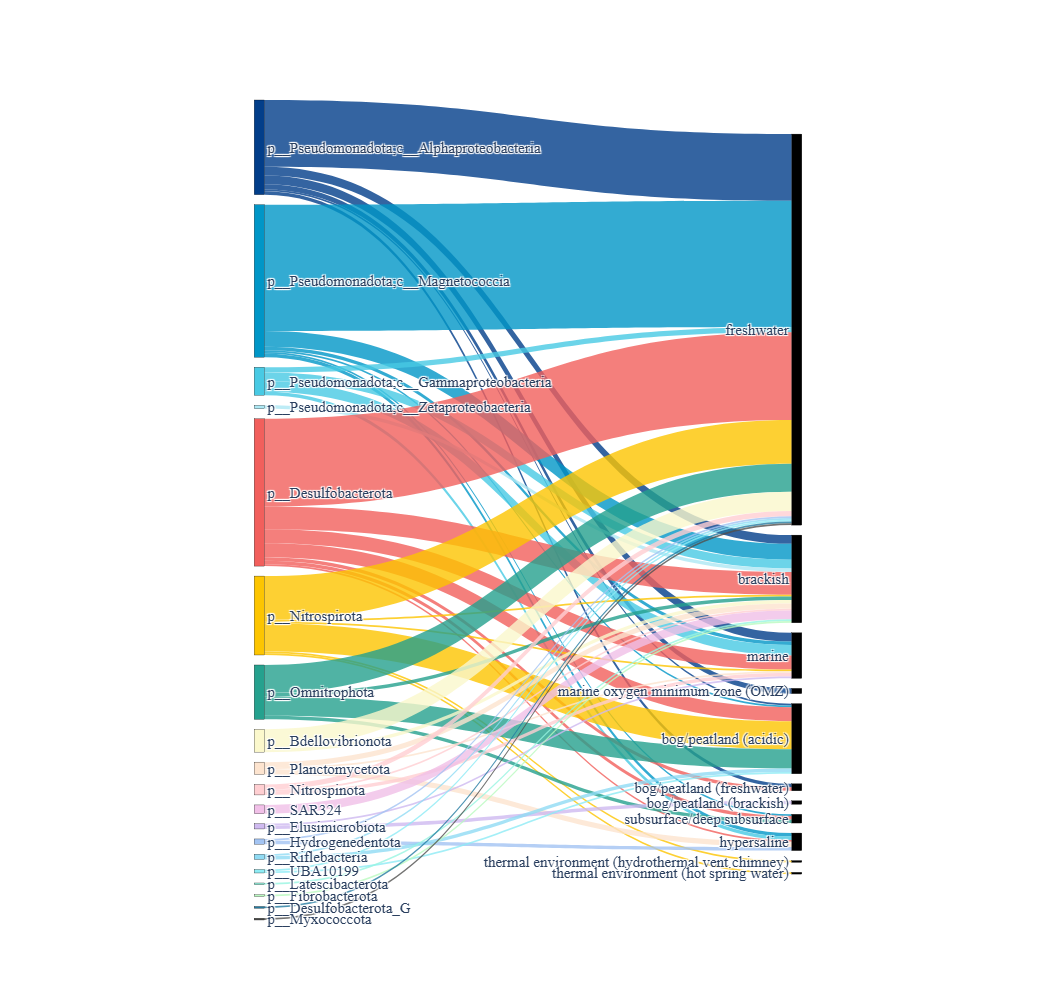

In [91]:
fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node = dict(
      pad = 10,
      thickness = 10,
      line = dict(color = 'black', width = 0.3),
      label = _label,
      color =colors+['black']*11,
      x=[0.2]*len(_y_taxa)+[0.8]*len(_y_env),
      y=_y,
    ),
    link = dict(
      source = _source,
      target = _target,
      value = _value,
      color=[hex_to_rgba(colors[i],0.8) for i in _source]
      # color=[colors[i] for i in _source],
  ))])

fig.update_layout(
    font=dict(
        family='Times New Roman'
    ),
    # title_text="Basic Sankey Diagram", 
    font_size=15,
    width=1000,
    height=1000
)
fig.show()

pio.write_image(fig, "sankey_diagram_0.8.svg")
# fig.write_html("sankey_diagram_0.8.html")


### Function